# Calibración del umbral de distancia (tarea 5.2b)

**Objetivo:** elegir, con datos, el **umbral de distancia euclidiana** del reconocedor
(`src/recognizer.py`), en lugar de dejar el valor por defecto de `face_recognition` (0.6).
El experimento 3 ya anticipó que **0.6 es permisivo** y que el corte natural está cerca de
**~0.5**; aquí lo confirmamos midiendo FAR y FRR.

## Cómo se mide
Se pasa un conjunto de rostros por el reconocedor y, para varios umbrales, se clasifica
cada resultado en una de 4 casillas:

| | Le da nombre (dist &lt; umbral) | Lo rechaza ("Desconocido") |
|---|---|---|
| **Persona conocida** | TP (acierto) | **FN** (falso rechazo) |
| **Persona desconocida** | **FP** (falsa aceptación) | TN (rechazo correcto) |

- **FRR** = FN / (TP + FN) — a un conocido se le niega el acceso.
- **FAR** = FP / (FP + TN) — a un intruso se le deja pasar.

Al subir el umbral (más permisivo) **FAR sube y FRR baja**; se cruzan en el **EER**
(Equal Error Rate), el umbral teóricamente óptimo. Como el caso de estudio es
**control de acceso**, se elige un umbral algo **más estricto** que el EER para
priorizar un **FAR bajo**.

## Fuentes de datos
- **Genuinos (TP/FN):** las fotos de gerardo, kevin y miguel, evaluadas con
  **leave-one-out** (el centroide de la persona se recalcula sin la foto que se está
  probando, para no compararla consigo misma → estima el caso real).
- **Impostores (FP/TN):**
  - **Externos:** `dataset/unknown_faces/` — personas reales que el sistema nunca registró.
  - **Leave-one-out:** cada conocido, sacado por completo de la base, actúa como intruso
    frente a los otros (añade más intentos de intruso, dado que las fotos externas son pocas).

## Salidas
- `experiments/calibracion_umbral.csv` — tabla TP/FN/FP/TN + FAR/FRR por umbral.
- `experiments/calibracion_umbral_curva.csv` — curva fina para reproducir el gráfico.
- `experiments/graphs/calibracion_umbral.png` — curvas FAR/FRR cruzadas con EER y umbral elegido.

## 1. Setup
Importa dependencias, ubica la raíz del proyecto y carga el detector YOLO una sola vez.
El pipeline de extracción de embeddings es el mismo de `src/embedding_db.py` / exp3.

In [1]:
import sys
import pickle
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import face_recognition
import matplotlib.pyplot as plt

# Ubicar la raiz del proyecto subiendo hasta encontrar src/
RAIZ = Path.cwd()
while not (RAIZ / "src").exists() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ))

from src.detector import FaceDetector

RUTA_KNOWN = RAIZ / "dataset" / "known_faces"
RUTA_UNKNOWN = RAIZ / "dataset" / "unknown_faces"
RUTA_MODELO_YOLO = RAIZ / "models" / "yolov8n-face.pt"
RUTA_GRAPHS = RAIZ / "experiments" / "graphs"
RUTA_GRAPHS.mkdir(parents=True, exist_ok=True)

print("Raiz    :", RAIZ)
print("Known   :", RUTA_KNOWN, "| existe:", RUTA_KNOWN.exists())
print("Unknown :", RUTA_UNKNOWN, "| existe:", RUTA_UNKNOWN.exists())

detector = FaceDetector(str(RUTA_MODELO_YOLO), conf_threshold=0.5)
print("\nDetector YOLO cargado.")

Raiz    : c:\Users\Gerardo\unmsm\7timo ciclo\IA\sistema-control-asistencia-facial
Known   : c:\Users\Gerardo\unmsm\7timo ciclo\IA\sistema-control-asistencia-facial\dataset\known_faces | existe: True
Unknown : c:\Users\Gerardo\unmsm\7timo ciclo\IA\sistema-control-asistencia-facial\dataset\unknown_faces | existe: True

Detector YOLO cargado.


## 2. Extracción de embeddings (conocidos y desconocidos)
Mismo pipeline que el registro: YOLO detecta el rostro de mayor confianza, se convierte
BGR→RGB y `face_recognition` genera el vector de 128-d.

In [2]:
EXTS = (".jpg", ".jpeg", ".png")

def listar_fotos(carpeta):
    return sorted(f for f in carpeta.glob("*") if f.suffix.lower() in EXTS)

def extraer_embedding(ruta):
    """YOLO detecta -> mejor rostro -> embedding 128-d. None si falla."""
    img = cv2.imread(str(ruta))
    if img is None:
        return None
    dets = detector.detect(img)
    if not dets:
        return None
    x1, y1, x2, y2, _ = max(dets, key=lambda d: d[4])
    loc = (y1, x2, y2, x1)  # (top, right, bottom, left)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    enc = face_recognition.face_encodings(rgb, known_face_locations=[loc])
    return enc[0] if enc else None

# Conocidos: {persona: [(archivo, emb), ...]}
emb_known = {}
print("Conocidos:")
for carpeta in sorted(p for p in RUTA_KNOWN.iterdir() if p.is_dir()):
    lst = []
    for ruta in listar_fotos(carpeta):
        e = extraer_embedding(ruta)
        if e is not None:
            lst.append((ruta.name, e))
    emb_known[carpeta.name] = lst
    print(f"  {carpeta.name:10s}: {len(lst)} embeddings")

# Desconocidos: [(archivo, emb), ...]
emb_unknown, fallos_unknown = [], []
for ruta in listar_fotos(RUTA_UNKNOWN):
    e = extraer_embedding(ruta)
    (emb_unknown.append((ruta.name, e)) if e is not None
     else fallos_unknown.append(ruta.name))
print(f"\nDesconocidos: {len(emb_unknown)} embeddings"
      + (f" | fallaron: {fallos_unknown}" if fallos_unknown else " (todas OK)"))

Conocidos:
  gerardo   : 15 embeddings
  kevin     : 21 embeddings
  miguel    : 15 embeddings

Desconocidos: 5 embeddings (todas OK)


## 3. Scores genuinos e impostores
El reconocedor compara contra el **centroide** de cada persona (promedio de sus embeddings),
igual que `src/recognizer.py`. Aquí se generan las distancias de cada intento.

In [3]:
nombres = list(emb_known.keys())

def centroide(embs):
    return np.mean(embs, axis=0)

def dist(a, b):
    return float(np.linalg.norm(a - b))

# Centroides con TODAS las fotos (como en recognizer.py)
centroides_full = {p: centroide([e for _, e in emb_known[p]]) for p in nombres}

# --- Genuinos (leave-one-out): (persona_real, persona_predicha, dist_min) ---
genuinos = []
for p in nombres:
    fotos = emb_known[p]
    for i, (arch, e) in enumerate(fotos):
        cents = dict(centroides_full)
        resto = [ee for j, (_, ee) in enumerate(fotos) if j != i]
        if resto:                       # centroide sin la foto de prueba
            cents[p] = centroide(resto)
        pred = min(nombres, key=lambda q: dist(e, cents[q]))
        genuinos.append((p, pred, dist(e, cents[pred])))

# --- Impostores ---
# (a) externos: personas reales nunca registradas
imp_externos = [min(dist(e, centroides_full[q]) for q in nombres)
                for _, e in emb_unknown]
# (b) leave-one-out: cada conocido, fuera de la base, contra los otros
imp_loo = []
for p in nombres:
    otros = [q for q in nombres if q != p]
    for _, e in emb_known[p]:
        imp_loo.append(min(dist(e, centroides_full[q]) for q in otros))

imp_todos = imp_externos + imp_loo   # conjunto de impostores principal

print(f"Genuinos            : {len(genuinos)}")
print(f"Impostores externos : {len(imp_externos)}  "
      f"(distancia minima a un conocido: {min(imp_externos):.3f})")
print(f"Impostores LOO      : {len(imp_loo)}")
print(f"Impostores total    : {len(imp_todos)}")
print("\nNota: los desconocidos externos quedan TODOS lejos (>0.6), asi que el FP "
      "que de verdad pesa es la confusion entre los conocidos (leave-one-out).")

Genuinos            : 51
Impostores externos : 5  (distancia minima a un conocido: 0.625)
Impostores LOO      : 51
Impostores total    : 56

Nota: los desconocidos externos quedan TODOS lejos (>0.6), asi que el FP que de verdad pesa es la confusion entre los conocidos (leave-one-out).


## 4. Tabla por umbral (FAR / FRR)
Para cada umbral se cuentan TP/FN/FP/TN y se calculan FAR y FRR. Se muestran los
cuatro umbrales pedidos por la tarea (0.4, 0.5, 0.6, 0.7).

In [4]:
def metricas(umbral, genuinos, impostores):
    # Genuino: TP si lo acepta (<umbral) y acierta la identidad; si no, FN.
    TP = sum(1 for real, pred, d in genuinos if d < umbral and pred == real)
    FN = len(genuinos) - TP
    # Impostor: FP si lo acepta, TN si lo rechaza.
    FP = sum(1 for d in impostores if d < umbral)
    TN = len(impostores) - FP
    FRR = FN / (TP + FN) if (TP + FN) else 0.0
    FAR = FP / (FP + TN) if (FP + TN) else 0.0
    return TP, FN, FP, TN, FAR, FRR

UMBRALES_TAREA = [0.4, 0.5, 0.6, 0.7]
filas = []
for u in UMBRALES_TAREA:
    TP, FN, FP, TN, FAR, FRR = metricas(u, genuinos, imp_todos)
    filas.append({"umbral": u, "TP": TP, "FN": FN, "FP": FP, "TN": TN,
                  "FAR_%": round(100 * FAR, 1), "FRR_%": round(100 * FRR, 1)})
df_umbral = pd.DataFrame(filas)
df_umbral

,umbral,TP,FN,FP,TN,FAR_%,FRR_%
0,0.4,45,6,1,55,1.8,11.8
1,0.5,47,4,31,25,55.4,7.8
2,0.6,48,3,49,7,87.5,5.9
3,0.7,48,3,54,2,96.4,5.9


## 5. Curva fina y EER
Se barre el umbral en pasos de 0.01 para trazar las curvas y localizar el **EER**
(punto donde FAR y FRR se cruzan).

In [5]:
grid = np.round(np.arange(0.30, 0.81, 0.01), 2)
FARs, FRRs = [], []
for u in grid:
    _, _, _, _, FAR, FRR = metricas(u, genuinos, imp_todos)
    FARs.append(FAR); FRRs.append(FRR)
FARs, FRRs = np.array(FARs), np.array(FRRs)

# EER: donde |FAR - FRR| es minimo
idx = int(np.argmin(np.abs(FARs - FRRs)))
eer_umbral = float(grid[idx])
eer_valor = float((FARs[idx] + FRRs[idx]) / 2)
print(f"EER ~ {eer_valor * 100:.1f}%  en umbral ~ {eer_umbral:.2f}")

EER ~ 7.5%  en umbral ~ 0.43


## 6. Selección del umbral final
Caso de estudio = **control de acceso** → se prioriza un **FAR bajo** (que no entre un
intruso) aunque el FRR suba un poco. Se elige el umbral **más permisivo que aún mantiene
FAR ≤ objetivo**, lo que da un punto **más estricto que el EER**.

In [6]:
FAR_OBJETIVO = 0.05   # como mucho 5% de intrusos aceptados

candidatos = [float(grid[i]) for i in range(len(grid)) if FARs[i] <= FAR_OBJETIVO]
UMBRAL_FINAL = round(max(candidatos), 2) if candidatos else eer_umbral

TPf, FNf, FPf, TNf, FARf, FRRf = metricas(UMBRAL_FINAL, genuinos, imp_todos)
print(f"EER (referencia)    : umbral {eer_umbral:.2f}")
print(f"Umbral FINAL elegido: {UMBRAL_FINAL:.2f}  (FAR objetivo <= {FAR_OBJETIVO*100:.0f}%)")
print(f"  En el umbral final -> FAR={FARf*100:.1f}%  FRR={FRRf*100:.1f}%")
print(f"  TP={TPf}  FN={FNf}  FP={FPf}  TN={TNf}")

EER (referencia)    : umbral 0.43
Umbral FINAL elegido: 0.40  (FAR objetivo <= 5%)
  En el umbral final -> FAR=1.8%  FRR=11.8%
  TP=45  FN=6  FP=1  TN=55


## 7. Gráfico de curvas FAR / FRR

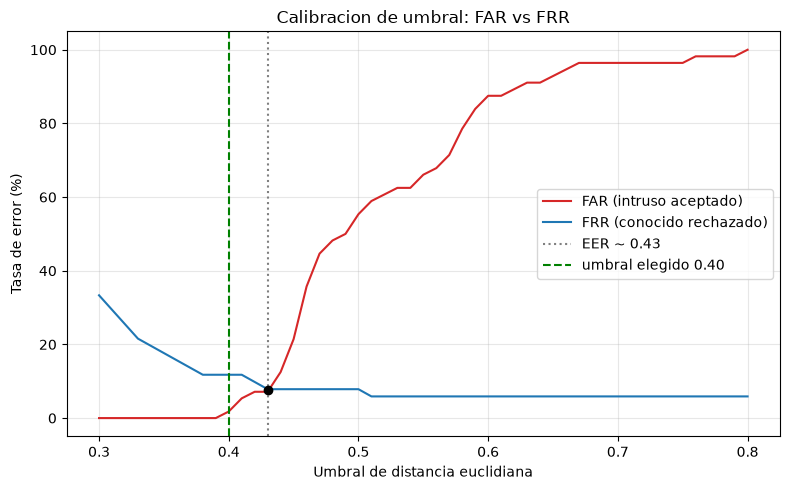

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(grid, FARs * 100, "-", color="tab:red",  label="FAR (intruso aceptado)")
plt.plot(grid, FRRs * 100, "-", color="tab:blue", label="FRR (conocido rechazado)")
plt.axvline(eer_umbral, color="gray", ls=":", label=f"EER ~ {eer_umbral:.2f}")
plt.plot(eer_umbral, eer_valor * 100, "ko")
plt.axvline(UMBRAL_FINAL, color="green", ls="--", label=f"umbral elegido {UMBRAL_FINAL:.2f}")
plt.xlabel("Umbral de distancia euclidiana")
plt.ylabel("Tasa de error (%)")
plt.title("Calibracion de umbral: FAR vs FRR")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(RUTA_GRAPHS / "calibracion_umbral.png", dpi=120)
plt.show()

## 8. Distribución de distancias (genuinos vs impostores)
Vista complementaria: dónde caen las distancias de los intentos genuinos (misma persona)
frente a las de los impostores. La línea del umbral elegido muestra el corte.

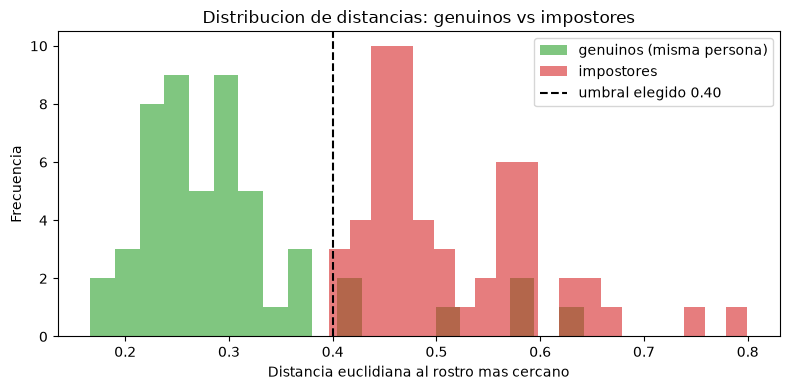

In [8]:
dist_genuinos = [d for _, _, d in genuinos]

plt.figure(figsize=(8, 4))
plt.hist(dist_genuinos, bins=20, alpha=0.6, color="tab:green",
         label="genuinos (misma persona)")
plt.hist(imp_todos, bins=20, alpha=0.6, color="tab:red", label="impostores")
plt.axvline(UMBRAL_FINAL, color="black", ls="--", label=f"umbral elegido {UMBRAL_FINAL:.2f}")
plt.xlabel("Distancia euclidiana al rostro mas cercano")
plt.ylabel("Frecuencia")
plt.title("Distribucion de distancias: genuinos vs impostores")
plt.legend(); plt.tight_layout()
plt.savefig(RUTA_GRAPHS / "calibracion_distribucion.png", dpi=120)
plt.show()

## 9. Guardar resultados (CSV)

In [9]:
# Tabla principal: umbrales de la tarea + filas de EER y umbral elegido
extra = []
for u, etiqueta in [(round(eer_umbral, 2), "EER"), (UMBRAL_FINAL, "ELEGIDO")]:
    TP, FN, FP, TN, FAR, FRR = metricas(u, genuinos, imp_todos)
    extra.append({"umbral": u, "TP": TP, "FN": FN, "FP": FP, "TN": TN,
                  "FAR_%": round(100 * FAR, 1), "FRR_%": round(100 * FRR, 1),
                  "nota": etiqueta})

df_out = df_umbral.copy()
df_out["nota"] = ""
df_out = pd.concat([df_out, pd.DataFrame(extra)], ignore_index=True)

RUTA_CSV = RAIZ / "experiments" / "calibracion_umbral.csv"
df_out.to_csv(RUTA_CSV, index=False, encoding="utf-8")

pd.DataFrame({"umbral": grid,
              "FAR_%": np.round(FARs * 100, 2),
              "FRR_%": np.round(FRRs * 100, 2)}
             ).to_csv(RAIZ / "experiments" / "calibracion_umbral_curva.csv", index=False)

print("Guardado:", RUTA_CSV)
df_out

Guardado: c:\Users\Gerardo\unmsm\7timo ciclo\IA\sistema-control-asistencia-facial\experiments\calibracion_umbral.csv


,umbral,TP,FN,FP,TN,FAR_%,FRR_%,nota
0,0.40,45,6,1,55,1.8,11.8,
1,0.50,47,4,31,25,55.4,7.8,
2,0.60,48,3,49,7,87.5,5.9,
3,0.70,48,3,54,2,96.4,5.9,
4,0.43,47,4,4,52,7.1,7.8,EER
5,0.40,45,6,1,55,1.8,11.8,ELEGIDO


## 10. Interpretación y conclusión

**Tabla por umbral (51 genuinos, 56 impostores = 5 externos + 51 leave-one-out):**

| umbral | TP | FN | FP | TN | FAR | FRR |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| 0.40 | 45 | 6 | 1 | 55 | **1.8%** | 11.8% |
| 0.50 | 47 | 4 | 31 | 25 | 55.4% | 7.8% |
| 0.60 | 48 | 3 | 49 | 7 | 87.5% | 5.9% |
| 0.70 | 48 | 3 | 54 | 2 | 96.4% | 5.9% |

**Lectura.** Al subir el umbral el sistema acepta más rostros: el **FRR baja** (rechaza a
menos conocidos) pero el **FAR se dispara**. Las curvas se cruzan en el **EER ≈ 7.5% sobre
un umbral ≈ 0.43**, el punto teóricamente óptimo si ambos errores costaran lo mismo.

**Un matiz importante.** Los **5 desconocidos reales** quedaron todos a distancia **≥ 0.62**
del conocido más cercano, así que con cualquier umbral ≤ 0.6 **ninguno entra**. El falso
positivo que de verdad pesa **no es el extraño, sino confundir a un conocido con otro**
(gerardo / kevin / miguel se parecen): por eso el FAR sube tan rápido pasado 0.45. Esto
**confirma con métricas** lo que el experimento 3 ya anticipaba: **0.6 — y hasta 0.5 — son
demasiado permisivos** para esta base.

**Decisión (control de acceso).** Un falso positivo (dejar pasar a quien no debe, o registrar
a la persona equivocada) es más grave que un falso negativo (pedir a un conocido que reintente,
cosa trivial en video porque hay muchos frames por segundo). Por eso se elige un umbral
**más estricto que el EER**: **0.40**, con **FAR 1.8%** a cambio de un **FRR 11.8%**. Bajar
el umbral de 0.43 a 0.40 reduce el FAR de ~7% a <2% subiendo el FRR solo unos puntos: un
intercambio favorable cuando la prioridad es la seguridad.

**Umbral final seleccionado: `0.40`.** Se fija como `threshold` por defecto en
`src/recognizer.py` y como `RECOGNITION_THRESHOLD` en `src/configuracion.py`, con un
comentario que justifica la decisión.

**Limitaciones.** (1) Solo 5 desconocidos externos → el FAR contra extraños se estima de
forma gruesa; se complementa con impostores *leave-one-out*. (2) Con solo 3 personas
enroladas y de aspecto parecido, el FAR por confusión de identidad es **pesimista**: con más
personas registradas el punto de operación podría relajarse algo. (3) El FRR de 11.8% es por
**foto**; en video, al evaluar muchos frames por persona, la probabilidad de no reconocer a un
conocido en *ningún* frame es mucho menor.